# Big Data Analytics Project
### Group 55 – NOVA IMS
##### Spring Semester 2024/2025

## 📑 Table of Contents
- [1. Importing Libraries](#1-importing-libraries)
- [2. Loading Data](#2-loading-the-dataset)
- [3. EDA](#3-eda)
- [4. Degrees](#4-degrees)
- [5. Label Propagation Algorithm](#5-lpa)
- [6. Clustering](#6-clustering)


## Importing Libraries

In [0]:
# import packages
import os
import pyspark
from pyspark.sql import SparkSession
from functools import reduce
from pyspark.sql import DataFrame
import pyspark.sql.functions as F
from pyspark.sql.functions import col, avg, min, max, count
from IPython.display import Image, display
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from pyspark.sql.types import IntegerType, NumericType, StringType
import builtins

from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.clustering import KMeans

from graphframes import GraphFrame
import networkx as nx


In [0]:
# Start Spark Session
spark = SparkSession.builder.appName("NYC Taxi Graph Analysis").getOrCreate()


## Loading Data

In [0]:
# Load the dataset
data = spark.read.parquet('/dbfs/FileStore/clean/dataset_after_cleaning.parquet')

In [0]:
# select columns and cast data types
df = data.selectExpr("cast(PUlocationID as int) as src",
                   "cast(DOlocationID as int) as dst",
                   "cast(trip_distance as double) as distance",
                   "cast(total_amount as double) as amount")
df.limit(8).display()

src,dst,distance,amount
68,163,2.06,38.5
163,233,1.2,18.48
230,90,1.49,21.0
236,161,2.18,31.08
138,166,8.51,60.09
237,100,2.55,27.24
132,100,17.41,98.88
239,166,1.81,18.48


In [0]:
# One of the location IDs is "other" -> casts to null
df.filter("src IS NULL OR dst IS NULL OR distance IS NULL OR amount IS NULL").show()

+----+----+--------+------+
| src| dst|distance|amount|
+----+----+--------+------+
|null|  71|     5.3|  26.0|
| 246|null|    22.6|113.58|
|null| 195|    7.14| 21.83|
| 132|null|   10.57| 72.95|
| 142|null|    19.5| 72.55|
| 132|null|    16.9| 82.19|
|null| 227|    3.31| 14.89|
| 132|null|   38.44|173.55|
|null| 223|     6.4|  38.0|
|null|  47|    16.8| 49.94|
|null| 186|    15.9| 43.94|
| 132|null|    9.84|  53.7|
|  42|null|    5.08|  27.8|
|null| 119|     3.4| 34.55|
|null| 254|     4.0|  23.0|
|  70|null|   10.78| 40.35|
|null| 129|    2.74|  16.4|
| 132|null|   17.53| 80.39|
|null| 226|    11.8|  47.0|
| 140|null|    18.3|  91.5|
+----+----+--------+------+
only showing top 20 rows



In [0]:
# drop any rows with null values
df = df.dropna()

In [0]:
# Vertices: unique locations
vertices = df.select("src").union(df.select("dst")).distinct().withColumnRenamed("src", "id")

# Edges: trips from pickup to dropoff
edges = df.select("src", "dst", "distance", "amount")

# Create the GraphFrame
gf = GraphFrame(vertices, edges)

/databricks/spark/python/pyspark/sql/dataframe.py:170: UserWarning: DataFrame.sql_ctx is an internal property, and will be removed in future releases. Use DataFrame.sparkSession instead.
  warnings.warn(


## EDA
Analyze the trips (most popular, expensive or longest)

In [0]:
# Aggregate to get average total_amount and distance as well as number of trips per edge (src → dst)
edge_agg = df.groupBy("src", "dst").agg(
    count("*").alias("trip_count"),
    avg("amount").alias("avg_amount"),
    avg("distance").alias("avg_distance")
)

# Find the most popular trips
edge_agg.orderBy('trip_count', ascending=False).limit(10).display()

src,dst,trip_count,avg_amount,avg_distance
237,236,760933,14.534422255310515,1.0749295930127891
236,237,645817,15.064193107335072,1.0559190916312189
237,237,504173,12.987817832370164,0.6662728071515154
236,236,484130,12.339374857991913,0.6515860822506352
264,264,474120,25.404639479457455,3.3621638403779586
161,237,341118,16.094792300610994,1.0873755122860698
237,161,331584,15.999713737694751,1.0718374227948286
161,236,292233,20.459652263775045,1.9589646959788916
142,239,287479,13.907123685555895,1.0081963204268831
239,142,280574,13.476223420559004,0.8883460691297134


In [0]:
# most expensive trips
edge_agg.orderBy('avg_amount', ascending=False).limit(10).display()

src,dst,trip_count,avg_amount,avg_distance
23,252,1,236.41,7.34
1,219,1,228.8,34.66
205,1,1,212.83,36.1
192,164,1,210.44,11.07
257,156,1,203.91,6.24
167,144,1,203.5,8.04
19,1,1,200.9,39.5
1,150,1,199.38,24.77
53,1,3,197.88333333333333,29.19333333333333
132,1,4595,197.60384766050055,36.40196082698586


In [0]:
# longest trips
edge_agg.orderBy('avg_distance', ascending=False).limit(10).display()

src,dst,trip_count,avg_amount,avg_distance
265,27,1,63.7,46.06
34,248,1,119.3,41.0
250,14,1,115.35,40.87
38,1,1,186.66,40.23
19,1,1,200.9,39.5
101,1,1,196.7,39.26
98,1,1,193.39,39.17
139,1,1,169.32,38.63
45,23,1,169.6,37.5
55,9,1,77.94,36.7


#### Visualize

In [0]:
# Get the Top 100 Most Trafficked Routes
top_routes = edge_agg.orderBy("trip_count", ascending=False).limit(100)

# convert to pandas
top_routes_pd = top_routes.toPandas()

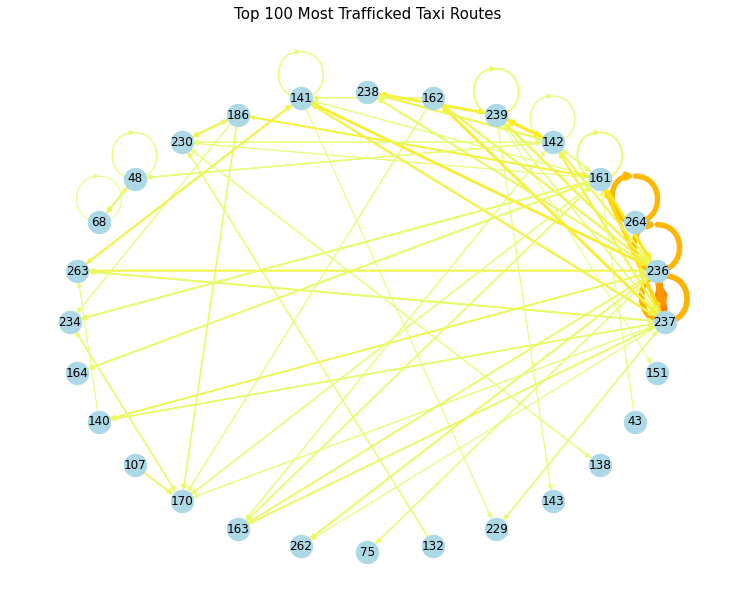

In [0]:
G = nx.DiGraph()

# Add edges and weights
for row in top_routes_pd.itertuples():
    G.add_edge(row.src, row.dst, weight=row.trip_count)

# Layout and draw
pos = nx.circular_layout(G) #nx.spring_layout(G, seed=42, k=10)
plt.figure(figsize=(10, 8))
edges = G.edges(data=True)
weights = [edata["weight"] for _, _, edata in edges]

# Normalize weights for better edge width scaling
min_width = 1
max_width = 9.0
min_val = builtins.min(weights)
max_val = builtins.max(weights)

# Normalize to [min_width, max_width]
scaled_widths = [
    min_width + (max_width - min_width) * ((w - min_val) / (max_val - min_val))
    for w in weights
]

nx.draw(G, pos, with_labels=True, node_size=500, node_color='lightblue', edge_color=weights, edge_cmap=plt.cm.Wistia, width=scaled_widths)
plt.title("Top 100 Most Trafficked Taxi Routes", fontsize=15)
plt.show()

## Degrees (In-Degree, Out-Degree)

In [0]:
# Number of incoming trips
in_degrees = gf.inDegrees.orderBy('inDegree', ascending=False)   
in_degrees.limit(10).display()

/databricks/spark/python/pyspark/sql/dataframe.py:149: UserWarning: DataFrame constructor is internal. Do not directly use it.
  warnings.warn("DataFrame constructor is internal. Do not directly use it.")


id,inDegree
236,4775246
237,4577733
161,4028553
230,3159427
170,3147613
142,2998379
239,2985149
162,2982924
141,2861544
68,2657440


In [0]:
# Number of outgoing trips
out_degrees = gf.outDegrees.orderBy('outDegree', ascending=False) 
out_degrees.limit(10).display()

id,outDegree
237,5233762
161,4903842
236,4616439
162,3828946
186,3746105
230,3594295
142,3584802
132,3377488
170,3252369
163,3172474


In [0]:
# common ids among the top 10 values
set(row["id"] for row in in_degrees.limit(10).collect()).intersection(row["id"] for row in out_degrees.limit(10).collect())

Out[10]: {48, 142, 161, 162, 230, 236, 237}

- 48,"Manhattan","Clinton East","Yellow Zone"
- 142,"Manhattan","Lincoln Square East","Yellow Zone"
- 161,"Manhattan","Midtown Center","Yellow Zone"
- 162,"Manhattan","Midtown East","Yellow Zone"
- 230,"Manhattan","Times Sq/Theatre District","Yellow Zone"
- 236,"Manhattan","Upper East Side North","Yellow Zone"
- 237,"Manhattan","Upper East Side South","Yellow Zone"

![](path)

## Label Propagation Algorithm (LPA) – Community Detection

In [0]:
# Filter edges with trip_count > threshold
threshold = 1000
filtered_edges = edge_agg.filter(edge_agg.trip_count > threshold)

# Get vertices connected by filtered edges
src_vertices = filtered_edges.select("src").distinct()
dst_vertices = filtered_edges.select("dst").distinct()
filtered_vertices = src_vertices.union(dst_vertices).distinct().withColumnRenamed("src", "id")

# Step 4: Create filtered GraphFrame
filtered_graph = GraphFrame(filtered_vertices, filtered_edges)

In [0]:
# apply label propagation algorithm
communities = filtered_graph.labelPropagation(maxIter=5)
communities.limit(10).display()

id,label
148,137
243,137
137,137
65,137
255,137
211,137
193,137
76,137
236,137
12,137


In [0]:
# only one community
communities.groupBy("label").agg(count("*").alias("count")).display()

label,count
137,216


## Clustering with K-Means (Using MLlib)

In [0]:
# per-node averages using outgoing trips
trip_stats = df.groupBy("src").agg(
    avg("amount").alias("avg_amount_out"),
    avg("distance").alias("avg_distance_out")
).withColumnRenamed("src", "id")

In [0]:
# Create feature df
features_df = (
    in_degrees.join(out_degrees, "id", "outer")
    .join(trip_stats, "id", "inner")
    .na.fill(0)  # fill any missing values with 0
)

In [0]:
# Assemble features into a vector
assembler = VectorAssembler(
    inputCols=["inDegree", "outDegree", "avg_amount_out", "avg_distance_out"],
    outputCol="features"
)
feature_vector = assembler.transform(features_df)

In [0]:
# apply K-means for same K as in 03_CLUSTERING notebook
kmeans = KMeans(k=3, seed=1)
model = kmeans.fit(feature_vector)

clusters = model.transform(feature_vector)

+---+----------+
| id|prediction|
+---+----------+
|  1|         0|
|  3|         0|
|  4|         0|
|  7|         0|
|  9|         0|
| 10|         0|
| 11|         0|
| 12|         0|
| 13|         0|
| 14|         0|
| 16|         0|
| 17|         0|
| 18|         0|
| 19|         0|
| 20|         0|
| 21|         0|
| 22|         0|
| 23|         0|
| 24|         0|
| 25|         0|
+---+----------+
only showing top 20 rows



In [0]:
# calculate number of locations in each cluster
cluster_counts = clusters.groupBy("prediction").agg(count("*").alias("count"))
cluster_counts.display()

prediction,count
1,3
2,32
0,182


#### Visualize Clusters

In [0]:
# create pandas df
pandas_df = clusters.toPandas()

/databricks/spark/python/pyspark/sql/pandas/conversion.py:122: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  Unable to convert the field features. If this column is not necessary, you may consider dropping it or converting to primitive type before the conversion.
Direct cause: Unsupported type in conversion to Arrow: VectorUDT()
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


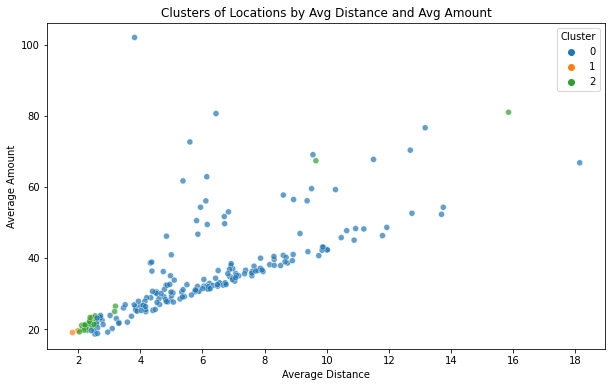

In [0]:
# plot clustering results against Avg Distance and Avg Amount
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=pandas_df,
    x="avg_distance_out",
    y="avg_amount_out",
    hue="prediction",
    palette="tab10",  # nice categorical colors
    alpha=0.7
)
plt.title("Clusters of Locations by Avg Distance and Avg Amount")
plt.xlabel("Average Distance")
plt.ylabel("Average Amount")
plt.legend(title="Cluster")
plt.show()

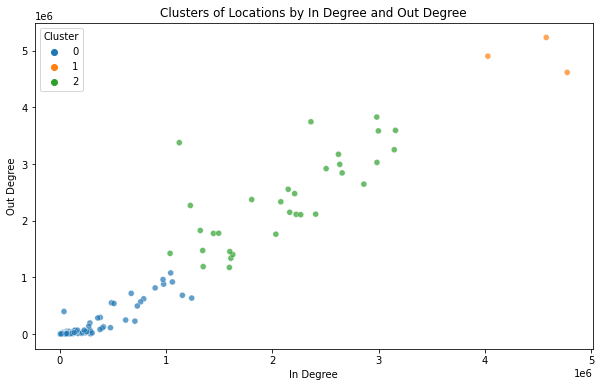

In [0]:
# plot clustering results against In Degrees and Out Degrees
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=pandas_df,
    x="inDegree",
    y="outDegree",
    hue="prediction",
    palette="tab10",  # nice categorical colors
    alpha=0.7
)
plt.title("Clusters of Locations by In Degree and Out Degree")
plt.xlabel("In Degree")
plt.ylabel("Out Degree")
plt.legend(title="Cluster")
plt.show()